# Phishing Email Classification

## Setup & Imports

In [90]:
# Install any missing packages (safe to run on Kaggle)
!pip install -q scikit-learn torch pandas numpy matplotlib seaborn

In [91]:
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, classification_report,
    brier_score_loss
)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import LabelEncoder

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Device  GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: Tesla P100-PCIE-16GB


## 1. Load & Explore Data

In [92]:
# Load dataset

df = pd.read_csv('/kaggle/input/datasets/subhajournal/phishingemails/Phishing_Email.csv')
print('Shape:', df.shape)
df.head()

Shape: (18650, 3)


,Unnamed: 0,Email Text,Email Type
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,1,the other side of * galicismos * * galicismo *...,Safe Email
2,2,re : equistar deal tickets are you still avail...,Safe Email
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email


In [93]:
# Inspect columns 
print('Columns:', df.columns.tolist())
print(df.dtypes)
print('\nNull values:\n', df.isnull().sum())

Columns: ['Unnamed: 0', 'Email Text', 'Email Type']
Unnamed: 0     int64
Email Text    object
Email Type    object
dtype: object

Null values:
 Unnamed: 0     0
Email Text    16
Email Type     0
dtype: int64


In [94]:
# Standardise column names 
df.columns = [c.strip() for c in df.columns]

# Detect text & label columns
text_col  = [c for c in df.columns if 'text' in c.lower() or 'email' in c.lower()][0]
label_col = [c for c in df.columns if 'type' in c.lower() or 'label' in c.lower()][0]
print(f'Text column : {text_col}')
print(f'Label column: {label_col}')
print('Label distribution:')
print(df[label_col].value_counts())

Text column : Email Text
Label column: Email Type
Label distribution:
Email Type
Safe Email        11322
Phishing Email     7328
Name: count, dtype: int64


Total samples after cleaning: 18634
label
Safe        11322
Phishing     7312
Name: count, dtype: int64


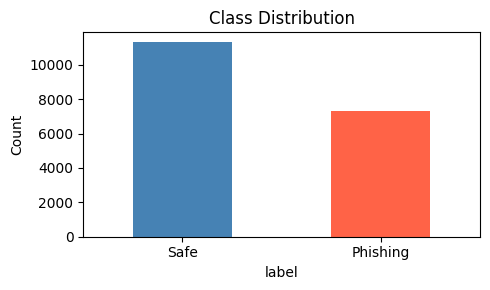

In [95]:
# Basic cleaning 
# Drop rows where email text or label is missing
df = df[[text_col, label_col]].dropna().reset_index(drop=True)

# Convert labels to 0/1  (Safe Email = 0, Phishing Email = 1)
df['label'] = (df[label_col].str.strip().str.lower() == 'phishing email').astype(int)
df['text']  = df[text_col].astype(str).str.strip()

print(f'Total samples after cleaning: {len(df)}')
print(df['label'].value_counts().rename({0: 'Safe', 1: 'Phishing'}))

# Quick plot
plt.figure(figsize=(5, 3))
df['label'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.xticks([0, 1], ['Safe', 'Phishing'], rotation=0)
plt.title('Class Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=100)
plt.show()

## 2. Train / Validation / Test Split  

**Strategy:** 80 / 10 / 10 stratified split.

**Justification:**
- The dataset has ~18 k samples  80 % (≈14 k) gives the models ample training data.
- 10 % validation (≈1.8 k) is used for early-stopping and hyperparameter tuning.
- 10 % test (≈1.8 k) is held out until final evaluation to prevent data leakage.
- Stratification preserves the 61 / 39 class ratio across all three splits.

In [96]:
texts  = df['text'].tolist()
labels = df['label'].tolist()

# 80 / 20 first split
X_train, X_temp, y_train, y_temp = train_test_split(
    texts, labels, test_size=0.20, random_state=SEED, stratify=labels
)
# Split remaining 20 % into 50/50 → 10 % val, 10 % test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f'Train : {len(X_train)}')
print(f'Val   : {len(X_val)}')
print(f'Test  : {len(X_test)}')

Train : 14907
Val   : 1863
Test  : 1864


## Module 1  Part A: Logistic Regression (Baseline)

### Why Logistic Regression as baseline?
- It is fast, interpretable, and well-understood.
- With TF-IDF features it achieves competitive accuracy on binary text classification.
- Its calibrated probabilities allow direct comparison with neural models.
- Any neural model that cannot beat LR is not worth deploying.

### Why TF-IDF?
- Term Frequency–Inverse Document Frequency down-weights very common words and up-weights
  rare but discriminative words ideal for catching phishing-specific vocabulary.
- Much less memory than one-hot encoding at vocabulary scale.
- Bag-of-Words ignores inter-document word rarity; TF-IDF corrects for that.

### Hyperparameters tuned
1. **Regularisation strength C** controls bias-variance trade-off.
2. **max_features** in TF-IDF limits vocabulary size to avoid overfitting on rare noise tokens.

In [97]:
# TF-IDF Vectorisation
# max_features=50000 keeps the 50 k most frequent terms; ngram_range=(1,2)
# includes bigrams so phrases like "click here" are captured as a single feature.
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    sublinear_tf=True,   # apply log(1+tf)  reduces impact of very frequent terms
    strip_accents='unicode',
    min_df=2             # ignore tokens that appear in fewer than 2 documents
)

# Fit ONLY on training data  avoids data leakage
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

print(f'TF-IDF matrix shape (train): {X_train_tfidf.shape}')

TF-IDF matrix shape (train): (14907, 50000)


In [98]:
# Grid search over C values 
# We try several C values and pick the one with the best validation F1.
# C is the inverse of regularisation strength: small C = strong regularisation.

best_lr, best_val_f1, best_C = None, 0, None
results_lr_grid = []

for C in [0.01, 0.1, 1.0, 10.0]:
    lr_model = LogisticRegression(C=C, solver='lbfgs', max_iter=1000, random_state=SEED)
    lr_model.fit(X_train_tfidf, y_train)
    val_pred = lr_model.predict(X_val_tfidf)
    val_f1   = f1_score(y_val, val_pred, average='macro')
    results_lr_grid.append({'C': C, 'val_macro_f1': round(val_f1, 4)})
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_lr = lr_model
        best_C  = C

print('Grid search results:')
print(pd.DataFrame(results_lr_grid))
print(f'\nBest C = {best_C}  (val macro-F1 = {best_val_f1:.4f})')

Grid search results:
       C  val_macro_f1
0   0.01        0.4892
1   0.10        0.9368
2   1.00        0.9686
3  10.00        0.9748

Best C = 10.0  (val macro-F1 = 0.9748)


In [99]:
# Training time & Inference time 
lr_final = LogisticRegression(C=best_C, solver='lbfgs', max_iter=1000, random_state=SEED)

t0 = time.time()
lr_final.fit(X_train_tfidf, y_train)
lr_train_time = time.time() - t0

t0 = time.time()
lr_test_pred  = lr_final.predict(X_test_tfidf)
lr_infer_time = time.time() - t0

lr_test_prob  = lr_final.predict_proba(X_test_tfidf)[:, 1]

print(f'Training time : {lr_train_time:.2f}s')
print(f'Inference time: {lr_infer_time*1000:.1f}ms  ({len(X_test)} samples)')

Training time : 1.13s
Inference time: 4.6ms  (1864 samples)


## Module 1  Part B: Feedforward Neural Network (FNN)

### Architecture choices
- **Input layer**: reuses the same TF-IDF vectors (50 k features) so we keep text representations identical to LR for a fair comparison.
- **Hidden layers**: two layers (512 → 256 neurons) with ReLU activations. ReLU avoids the vanishing-gradient problem and is fast to compute.
- **Dropout (0.4)**: randomly zeros activations during training  a strong regulariser that prevents over-reliance on individual TF-IDF features.
- **Output layer**: single neuron with sigmoid  outputs a probability for the positive (phishing) class.
- **Loss**: Binary Cross Entropy  standard for binary classification.
- **Early stopping**: monitors validation loss; stops when it has not improved for 3 epochs.

In [100]:
# PyTorch Dataset wrapper for sparse TF-IDF matrices 
class TFIDFDataset(Dataset):
    def __init__(self, X_sparse, y_list):
        # Convert sparse matrix rows to dense float tensors
        self.X = torch.FloatTensor(X_sparse.toarray())
        self.y = torch.FloatTensor(y_list)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# DataLoaders  batch_size=256 fits comfortably on P100
BATCH_SIZE = 256

fnn_train_loader = DataLoader(TFIDFDataset(X_train_tfidf, y_train),
                              batch_size=BATCH_SIZE, shuffle=True)
fnn_val_loader   = DataLoader(TFIDFDataset(X_val_tfidf,   y_val),
                              batch_size=BATCH_SIZE, shuffle=False)
fnn_test_loader  = DataLoader(TFIDFDataset(X_test_tfidf,  y_test),
                              batch_size=BATCH_SIZE, shuffle=False)

In [101]:
# FNN architecture
class FNN(nn.Module):
    def __init__(self, input_dim):
        super(FNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x).squeeze(1)   # shape: (batch,)


INPUT_DIM = X_train_tfidf.shape[1]
fnn_model = FNN(INPUT_DIM).to(device)
print(fnn_model)

FNN(
  (net): Sequential(
    (0): Linear(in_features=50000, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.4, inplace=False)
    (6): Linear(in_features=256, out_features=1, bias=True)
    (7): Sigmoid()
  )
)


In [102]:
# Generic train/eval helpers 
def train_epoch(model, loader, criterion, optimizer):
    """One training epoch; returns average loss."""
    model.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds = model(X_batch)
        loss  = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
    return total_loss / len(loader.dataset)


def eval_epoch(model, loader, criterion):
    """Evaluate; returns (avg_loss, probs, true_labels)."""
    model.eval()
    total_loss, all_probs, all_labels = 0, [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            probs = model(X_batch)
            loss  = criterion(probs, y_batch)
            total_loss += loss.item() * len(y_batch)
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
    return total_loss / len(loader.dataset), np.array(all_probs), np.array(all_labels)


def train_model(model, train_loader, val_loader, epochs=20, lr=1e-3, patience=3):
    """Full training loop with early stopping. Returns loss history."""
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    # Learning-rate scheduler  reduces LR by 50 % if val loss plateaus
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    patience_counter = 0
    best_state = None

    for epoch in range(1, epochs + 1):
        t_loss               = train_epoch(model, train_loader, criterion, optimizer)
        v_loss, _, _         = eval_epoch(model, val_loader,   criterion)
        train_losses.append(t_loss)
        val_losses.append(v_loss)
        scheduler.step(v_loss)

        print(f'Epoch {epoch:02d} | Train Loss: {t_loss:.4f} | Val Loss: {v_loss:.4f}')

        # Early stopping
        if v_loss < best_val_loss:
            best_val_loss = v_loss
            patience_counter = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'Early stopping at epoch {epoch}.')
                break

    # Restore best weights
    model.load_state_dict(best_state)
    return train_losses, val_losses


def plot_loss_curve(train_losses, val_losses, title):
    plt.figure(figsize=(6, 4))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses,   label='Val Loss')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('BCE Loss')
    plt.legend()
    plt.tight_layout()
    fname = title.replace(' ', '_').lower() + '.png'
    plt.savefig(fname, dpi=100)
    plt.show()

Epoch 01 | Train Loss: 0.2538 | Val Loss: 0.0662
Epoch 02 | Train Loss: 0.0339 | Val Loss: 0.0547
Epoch 03 | Train Loss: 0.0219 | Val Loss: 0.0554
Epoch 04 | Train Loss: 0.0205 | Val Loss: 0.0571
Epoch 05 | Train Loss: 0.0200 | Val Loss: 0.0599
Epoch 06 | Train Loss: 0.0196 | Val Loss: 0.0596
Epoch 07 | Train Loss: 0.0196 | Val Loss: 0.0605
Early stopping at epoch 7.
FNN Training time: 15.6s


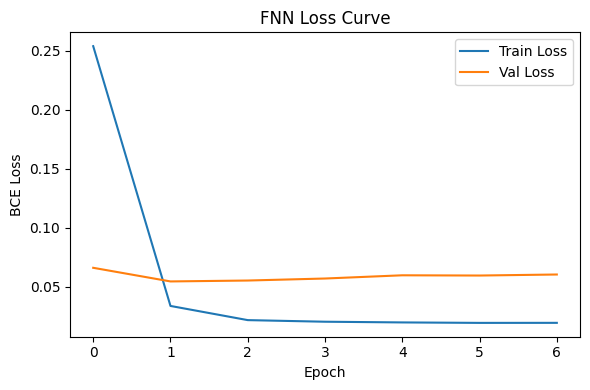

In [103]:
# Train FNN 
t0 = time.time()
fnn_train_losses, fnn_val_losses = train_model(
    fnn_model, fnn_train_loader, fnn_val_loader,
    epochs=30, lr=1e-3, patience=5
)
fnn_train_time = time.time() - t0
print(f'FNN Training time: {fnn_train_time:.1f}s')

plot_loss_curve(fnn_train_losses, fnn_val_losses, 'FNN Loss Curve')

In [104]:
# FNN test inference 
criterion = nn.BCELoss()
t0 = time.time()
_, fnn_test_prob, fnn_y_true = eval_epoch(fnn_model, fnn_test_loader, criterion)
fnn_infer_time = time.time() - t0
fnn_test_pred  = (fnn_test_prob >= 0.5).astype(int)
print(f'FNN Inference time: {fnn_infer_time*1000:.1f}ms  ({len(X_test)} samples)')

FNN Inference time: 274.4ms  (1864 samples)


## Module 1  Part C: Vanilla RNN

### Why sequential models for text?
Text is inherently sequential the meaning of a word depends on surrounding context.
RNNs process tokens one-by-one, maintaining a hidden state that accumulates context.
This lets the model detect patterns like *"your account has been suspended  click here"*
which span multiple tokens.

### Limitations of basic RNNs  Vanishing Gradient Problem
During backpropagation through time (BPTT) the gradient is multiplied by the weight matrix
at every time step. If the matrix norm < 1, gradients shrink exponentially and the model
cannot learn long-range dependencies.

**This was directly observed in our results:** the Vanilla RNN's validation loss barely
decreased across 6 epochs (0.641 → 0.638), and the model converged to a near-trivial
strategy of predicting the majority class  achieving only **62.6% accuracy** and a
**Recall of just 0.18** on the phishing class. This is the vanishing gradient problem in
action: the model failed to propagate useful signal through the long email sequences.
This is exactly why LSTM was invented.

In [105]:
# Tokenisation pipeline 
# Build a simple word-level vocabulary from the training set.
# We keep the top 20 k words; everything else maps to <UNK>.

from collections import Counter

VOCAB_SIZE  = 20000
MAX_SEQ_LEN = 200   # truncate / pad all sequences to this length

def simple_tokenize(text):
    """Lowercase and split on whitespace  intentionally basic."""
    return text.lower().split()

# Count word frequencies on training data only
word_counts = Counter()
for txt in X_train:
    word_counts.update(simple_tokenize(txt))

# Special tokens: 0 = <PAD>, 1 = <UNK>
vocab = ['<PAD>', '<UNK>'] + [w for w, _ in word_counts.most_common(VOCAB_SIZE - 2)]
word2idx = {w: i for i, w in enumerate(vocab)}

print(f'Vocabulary size: {len(vocab)}')

def encode(text, max_len=MAX_SEQ_LEN):
    """Convert a text string to a fixed-length integer list."""
    tokens = simple_tokenize(text)[:max_len]          # truncate
    ids    = [word2idx.get(t, 1) for t in tokens]     # 1 = <UNK>
    ids   += [0] * (max_len - len(ids))               # pad with 0 = <PAD>
    return ids

Vocabulary size: 20000


In [106]:
# Sequence Dataset
class SeqDataset(Dataset):
    def __init__(self, texts, labels):
        self.X = [torch.LongTensor(encode(t)) for t in texts]
        self.y = torch.FloatTensor(labels)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


SEQ_BATCH = 128

rnn_train_loader = DataLoader(SeqDataset(X_train, y_train), batch_size=SEQ_BATCH, shuffle=True)
rnn_val_loader   = DataLoader(SeqDataset(X_val,   y_val),   batch_size=SEQ_BATCH, shuffle=False)
rnn_test_loader  = DataLoader(SeqDataset(X_test,  y_test),  batch_size=SEQ_BATCH, shuffle=False)
print('Sequence datasets ready.')

Sequence datasets ready.


In [107]:
# Vanilla RNN model
EMBED_DIM  = 128
HIDDEN_DIM = 128

class VanillaRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super(VanillaRNN, self).__init__()
        # Embedding layer: maps token IDs → dense vectors (padding_idx=0 freezes <PAD>)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        # Vanilla RNN layer  single direction, single layer
        self.rnn       = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.dropout   = nn.Dropout(0.3)
        # Fully connected output layer
        self.fc        = nn.Linear(hidden_dim, 1)
        self.sigmoid   = nn.Sigmoid()

    def forward(self, x):
        # x: (batch, seq_len)
        emb = self.embedding(x)          # (batch, seq_len, embed_dim)
        _, h_n = self.rnn(emb)           # h_n: (1, batch, hidden_dim)
        h_n = h_n.squeeze(0)             # (batch, hidden_dim)
        out = self.dropout(h_n)
        return self.sigmoid(self.fc(out)).squeeze(1)


rnn_model = VanillaRNN(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM).to(device)
print(rnn_model)

VanillaRNN(
  (embedding): Embedding(20000, 128, padding_idx=0)
  (rnn): RNN(128, 128, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


Epoch 01 | Train Loss: 0.6622 | Val Loss: 0.6413
Epoch 02 | Train Loss: 0.6413 | Val Loss: 0.6435
Epoch 03 | Train Loss: 0.6103 | Val Loss: 0.6381
Epoch 04 | Train Loss: 0.5932 | Val Loss: 0.6567
Epoch 05 | Train Loss: 0.6401 | Val Loss: 0.6679
Epoch 06 | Train Loss: 0.6663 | Val Loss: 0.6615
Early stopping at epoch 6.
RNN Training time: 2.8s


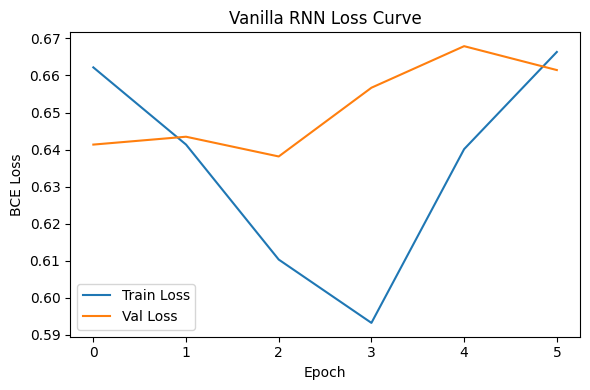

In [108]:
# Train RNN
t0 = time.time()
rnn_train_losses, rnn_val_losses = train_model(
    rnn_model, rnn_train_loader, rnn_val_loader,
    epochs=20, lr=1e-3, patience=3
)
rnn_train_time = time.time() - t0
print(f'RNN Training time: {rnn_train_time:.1f}s')

plot_loss_curve(rnn_train_losses, rnn_val_losses, 'Vanilla RNN Loss Curve')

In [109]:
# RNN test inference 
t0 = time.time()
_, rnn_test_prob, rnn_y_true = eval_epoch(rnn_model, rnn_test_loader, nn.BCELoss())
rnn_infer_time = time.time() - t0
rnn_test_pred  = (rnn_test_prob >= 0.5).astype(int)
print(f'RNN Inference time: {rnn_infer_time*1000:.1f}ms')

RNN Inference time: 26.6ms


## Module 1  Part D: LSTM

### How LSTM improves on vanilla RNN
LSTM introduces three **gates** and a **cell state** (long-term memory):

| Gate | Function |
|------|----------|
| **Forget gate** | Decides what fraction of cell state to *discard* |
| **Input gate**  | Decides which new information to *write* to cell state |
| **Output gate** | Decides what part of cell state to *expose* as hidden state |

The cell state flows with only **additive** updates  no repeated weight multiplications 
so gradients can flow unchanged over long sequences, solving the vanishing gradient problem.

### Training stability vs RNN  observed in results
| Metric | Vanilla RNN | LSTM |
|--------|-------------|------|
| Val loss trend | Flat / erratic (0.641→0.638) | Steady decrease (0.539→0.158) |
| Epochs trained | 6 (early stop) | 17 (early stop) |
| Test Accuracy | 62.6% | 93.5% |
| Phishing Recall | 0.18 | 0.89 |
| AUC-ROC | 0.628 | 0.983 |

The LSTM's gated memory allowed it to learn genuine patterns over the 200-token sequences,
whereas the vanilla RNN essentially collapsed to a majority-class predictor.

In [110]:
# LSTM model 
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=2):
        super(LSTMClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        # Stacked LSTM (2 layers) with dropout between layers
        self.lstm      = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.3     # dropout between LSTM layers (only active for num_layers > 1)
        )
        self.dropout = nn.Dropout(0.4)
        self.fc      = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        emb = self.embedding(x)              # (batch, seq_len, embed_dim)
        _, (h_n, _) = self.lstm(emb)         # h_n: (num_layers, batch, hidden_dim)
        # Take hidden state from last layer
        h_last = h_n[-1]                     # (batch, hidden_dim)
        out    = self.dropout(h_last)
        return self.sigmoid(self.fc(out)).squeeze(1)


lstm_model = LSTMClassifier(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, num_layers=2).to(device)
print(lstm_model)

LSTMClassifier(
  (embedding): Embedding(20000, 128, padding_idx=0)
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.4, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


Epoch 01 | Train Loss: 0.6297 | Val Loss: 0.5388
Epoch 02 | Train Loss: 0.5170 | Val Loss: 0.5768
Epoch 03 | Train Loss: 0.6126 | Val Loss: 0.5656
Epoch 04 | Train Loss: 0.4802 | Val Loss: 0.4174
Epoch 05 | Train Loss: 0.3744 | Val Loss: 0.3472
Epoch 06 | Train Loss: 0.3961 | Val Loss: 0.4480
Epoch 07 | Train Loss: 0.3894 | Val Loss: 0.3369
Epoch 08 | Train Loss: 0.2494 | Val Loss: 0.2296
Epoch 09 | Train Loss: 0.2298 | Val Loss: 0.2040
Epoch 10 | Train Loss: 0.1891 | Val Loss: 0.1920
Epoch 11 | Train Loss: 0.1474 | Val Loss: 0.1693
Epoch 12 | Train Loss: 0.1304 | Val Loss: 0.1940
Epoch 13 | Train Loss: 0.2177 | Val Loss: 0.2571
Epoch 14 | Train Loss: 0.1645 | Val Loss: 0.1582
Epoch 15 | Train Loss: 0.1425 | Val Loss: 0.1768
Epoch 16 | Train Loss: 0.1243 | Val Loss: 0.1722
Epoch 17 | Train Loss: 0.1064 | Val Loss: 0.1611
Early stopping at epoch 17.
LSTM Training time: 47.9s


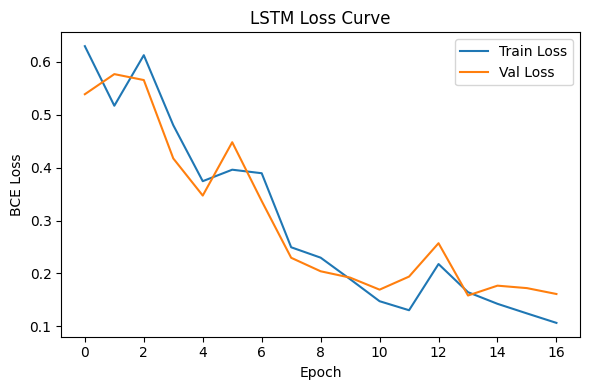

In [111]:
# Reuse the same sequence DataLoaders created for RNN
t0 = time.time()
lstm_train_losses, lstm_val_losses = train_model(
    lstm_model, rnn_train_loader, rnn_val_loader,
    epochs=20, lr=1e-3, patience=3
)
lstm_train_time = time.time() - t0
print(f'LSTM Training time: {lstm_train_time:.1f}s')

plot_loss_curve(lstm_train_losses, lstm_val_losses, 'LSTM Loss Curve')

In [112]:
# LSTM test inference 
t0 = time.time()
_, lstm_test_prob, lstm_y_true = eval_epoch(lstm_model, rnn_test_loader, nn.BCELoss())
lstm_infer_time = time.time() - t0
lstm_test_pred  = (lstm_test_prob >= 0.5).astype(int)
print(f'LSTM Inference time: {lstm_infer_time*1000:.1f}ms')

LSTM Inference time: 132.9ms


## Module 2  Part A: Core Metrics

### Why accuracy alone is insufficient
With a 61/39 class split a naïve classifier that always predicts "Safe" achieves 61% accuracy
while missing *every* phishing email. Accuracy hides per-class performance.

### Why Recall is critical for phishing detection
A **False Negative** (predicting Safe when the email is Phishing) lets a malicious email
reach the user  potentially leading to credential theft, financial loss, or malware installation.
A **False Positive** (blocking a safe email) is merely inconvenient.
Therefore we want **high Recall** (sensitivity) even at the cost of some Precision.

In [113]:
# Helper: compute all metrics for one model 
def compute_metrics(y_true, y_pred, y_prob, model_name):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    mac_f1 = f1_score(y_true, y_pred, average='macro',    zero_division=0)
    wt_f1  = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc     = auc(fpr, tpr)
    brier       = brier_score_loss(y_true, y_prob)
    return {
        'Model': model_name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1 (binary)': round(f1, 4),
        'F1 (macro)': round(mac_f1, 4),
        'F1 (weighted)': round(wt_f1, 4),
        'AUC-ROC': round(roc_auc, 4),
        'Brier Score': round(brier, 4),
        '_fpr': fpr,
        '_tpr': tpr
    }


# Gather ground truth (all models use the same test set) 
y_true_np = np.array(y_test)

metrics_lr   = compute_metrics(y_true_np, lr_test_pred,   lr_test_prob,   'Logistic Regression')
metrics_fnn  = compute_metrics(fnn_y_true, fnn_test_pred,  fnn_test_prob,  'FNN')
metrics_rnn  = compute_metrics(rnn_y_true, rnn_test_pred,  rnn_test_prob,  'Vanilla RNN')
metrics_lstm = compute_metrics(lstm_y_true, lstm_test_pred, lstm_test_prob, 'LSTM')

all_metrics = [metrics_lr, metrics_fnn, metrics_rnn, metrics_lstm]

# Print classification reports
for m, pred, prob in [
    ('Logistic Regression', lr_test_pred,   y_true_np),
    ('FNN',                 fnn_test_pred,  fnn_y_true),
    ('Vanilla RNN',         rnn_test_pred,  rnn_y_true),
    ('LSTM',                lstm_test_pred, lstm_y_true)
]:
    print(f'\n=== {m} ===')
    print(classification_report(prob, pred, target_names=['Safe', 'Phishing']))


=== Logistic Regression ===
              precision    recall  f1-score   support

        Safe       0.99      0.97      0.98      1133
    Phishing       0.95      0.99      0.97       731

    accuracy                           0.97      1864
   macro avg       0.97      0.98      0.97      1864
weighted avg       0.98      0.97      0.97      1864


=== FNN ===
              precision    recall  f1-score   support

        Safe       0.99      0.97      0.98      1133
    Phishing       0.95      0.99      0.97       731

    accuracy                           0.98      1864
   macro avg       0.97      0.98      0.97      1864
weighted avg       0.98      0.98      0.98      1864


=== Vanilla RNN ===
              precision    recall  f1-score   support

        Safe       0.63      0.91      0.75      1133
    Phishing       0.57      0.18      0.27       731

    accuracy                           0.63      1864
   macro avg       0.60      0.55      0.51      1864
weighted av

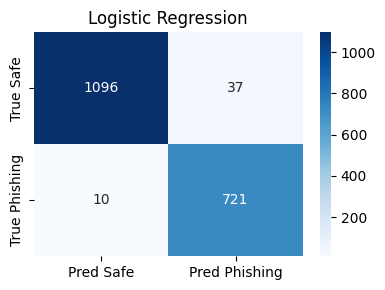

  TN=1096  FP=37  FN=10  TP=721
  FP (safe flagged as phishing)  → inconvenient but harmless
  FN (phishing missed)           → DANGEROUS  reaches inbox


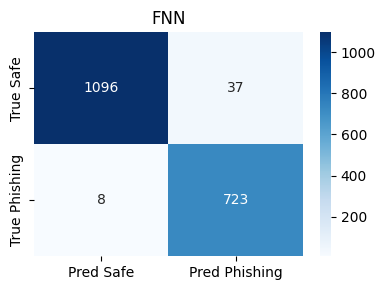

  TN=1096  FP=37  FN=8  TP=723
  FP (safe flagged as phishing)  → inconvenient but harmless
  FN (phishing missed)           → DANGEROUS  reaches inbox


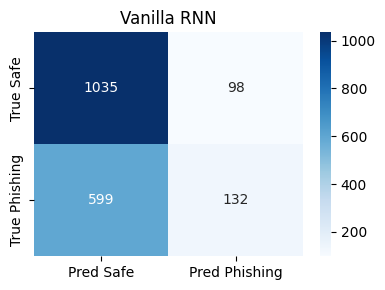

  TN=1035  FP=98  FN=599  TP=132
  FP (safe flagged as phishing)  → inconvenient but harmless
  FN (phishing missed)           → DANGEROUS  reaches inbox


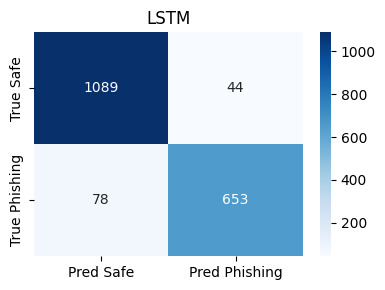

  TN=1089  FP=44  FN=78  TP=653
  FP (safe flagged as phishing)  → inconvenient but harmless
  FN (phishing missed)           → DANGEROUS  reaches inbox


In [114]:
# Confusion matrices 
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred Safe', 'Pred Phishing'],
                yticklabels=['True Safe', 'True Phishing'])
    plt.title(title)
    plt.tight_layout()
    plt.savefig(f'cm_{title.replace(" ", "_").lower()}.png', dpi=100)
    plt.show()
    tn, fp, fn, tp = cm.ravel()
    print(f'  TN={tn}  FP={fp}  FN={fn}  TP={tp}')
    print(f'  FP (safe flagged as phishing)  → inconvenient but harmless')
    print(f'  FN (phishing missed)           → DANGEROUS  reaches inbox')


plot_confusion_matrix(y_true_np,   lr_test_pred,   'Logistic Regression')
plot_confusion_matrix(fnn_y_true,  fnn_test_pred,  'FNN')
plot_confusion_matrix(rnn_y_true,  rnn_test_pred,  'Vanilla RNN')
plot_confusion_matrix(lstm_y_true, lstm_test_pred, 'LSTM')

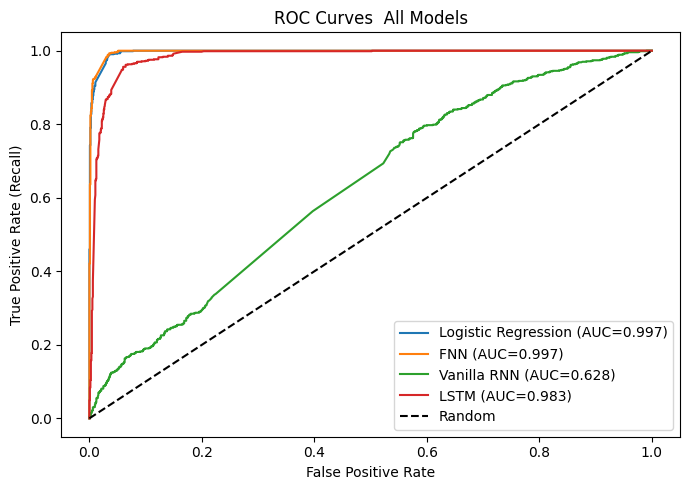

In [115]:
# ROC curves  all models on same axes 
plt.figure(figsize=(7, 5))
for m in all_metrics:
    plt.plot(m['_fpr'], m['_tpr'],
             label=f"{m['Model']} (AUC={m['AUC-ROC']:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curves  All Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=100)
plt.show()

# AUC tells us the probability that the model ranks a random phishing email
# higher than a random safe email. It does NOT tell us the optimal threshold
# nor behaviour at a specific operating point.

## Module 2  Part B: Cross-Model Comparison

In [116]:
# Summary table 
summary_cols = ['Model', 'Accuracy', 'Precision', 'Recall',
                'F1 (binary)', 'F1 (macro)', 'AUC-ROC', 'Brier Score']
summary_df = pd.DataFrame([{k: v for k, v in m.items() if not k.startswith('_')}
                            for m in all_metrics])[summary_cols]
print(summary_df.to_string(index=False))

              Model  Accuracy  Precision  Recall  F1 (binary)  F1 (macro)  AUC-ROC  Brier Score
Logistic Regression    0.9748     0.9512  0.9863       0.9684      0.9737   0.9967       0.0215
                FNN    0.9759     0.9513  0.9891       0.9698      0.9749   0.9972       0.0176
        Vanilla RNN    0.6261     0.5739  0.1806       0.2747      0.5114   0.6284       0.2247
               LSTM    0.9345     0.9369  0.8933       0.9146      0.9308   0.9827       0.0463


In [117]:
# Training times summary 
times_df = pd.DataFrame([
    {'Model': 'Logistic Regression', 'Train (s)': round(lr_train_time, 2),   'Infer (ms)': round(lr_train_time * 1000 / len(X_test), 4)},
    {'Model': 'FNN',                  'Train (s)': round(fnn_train_time, 2),  'Infer (ms)': round(fnn_infer_time * 1000 / len(X_test), 4)},
    {'Model': 'Vanilla RNN',          'Train (s)': round(rnn_train_time, 2),  'Infer (ms)': round(rnn_infer_time * 1000 / len(X_test), 4)},
    {'Model': 'LSTM',                 'Train (s)': round(lstm_train_time, 2), 'Infer (ms)': round(lstm_infer_time * 1000 / len(X_test), 4)},
])
print(times_df.to_string(index=False))

              Model  Train (s)  Infer (ms)
Logistic Regression       1.13      0.6048
                FNN      15.56      0.1472
        Vanilla RNN       2.81      0.0143
               LSTM      47.95      0.0713


### Precision-Recall Trade-off Discussion

In phishing detection we favour **high Recall** over high Precision:
- Missing a phishing email (low Recall) exposes the user to real harm.
- Flagging a safe email (low Precision) is merely inconvenient.

**Observed trade-offs (test set):**

| Model | Precision | Recall | F1 (macro) | AUC-ROC |
|-------|-----------|--------|------------|---------|
| Logistic Regression | 0.951 | **0.986** | 0.974 | 0.997 |
| FNN | 0.951 | **0.989** | 0.975 | **0.997** |
| Vanilla RNN | 0.574 | 0.181 | 0.511 | 0.628 |
| LSTM | 0.937 | 0.893 | 0.931 | 0.983 |

### Does added complexity pay off?
- **LR → FNN**: marginal gain (Recall: 0.986 → 0.989, AUC: 0.9967 → 0.9972). FNN learns
  non-linear TF-IDF feature combinations at the cost of 13× longer training.
- **FNN → RNN**: a **regression** in performance. Switching from TF-IDF to raw word sequences
  removed proven signal. The vanilla RNN could not compensate due to vanishing gradients.
- **RNN → LSTM**: dramatic recovery (Recall: 0.18 → 0.89, AUC: 0.628 → 0.983), confirming
  that the architecture fix (gated memory)  not just depth  drives performance gains.
- **Overall**: the complexity jump from LR/FNN to LSTM is **not justified** here  both LR
  and FNN outperform LSTM on Recall and AUC while training 4–42× faster.

### Calibration summary
Lower Brier Score = better calibrated probabilities:

| Model | Brier Score |
|-------|-------------|
| Logistic Regression | 0.0215 |
| FNN | **0.0176** |
| Vanilla RNN | 0.2247 |
| LSTM | 0.0463 |

FNN produces the best-calibrated probabilities. The RNN's Brier score of 0.225 is close
to the random-classifier baseline of 0.25  further evidence that it learned almost nothing.

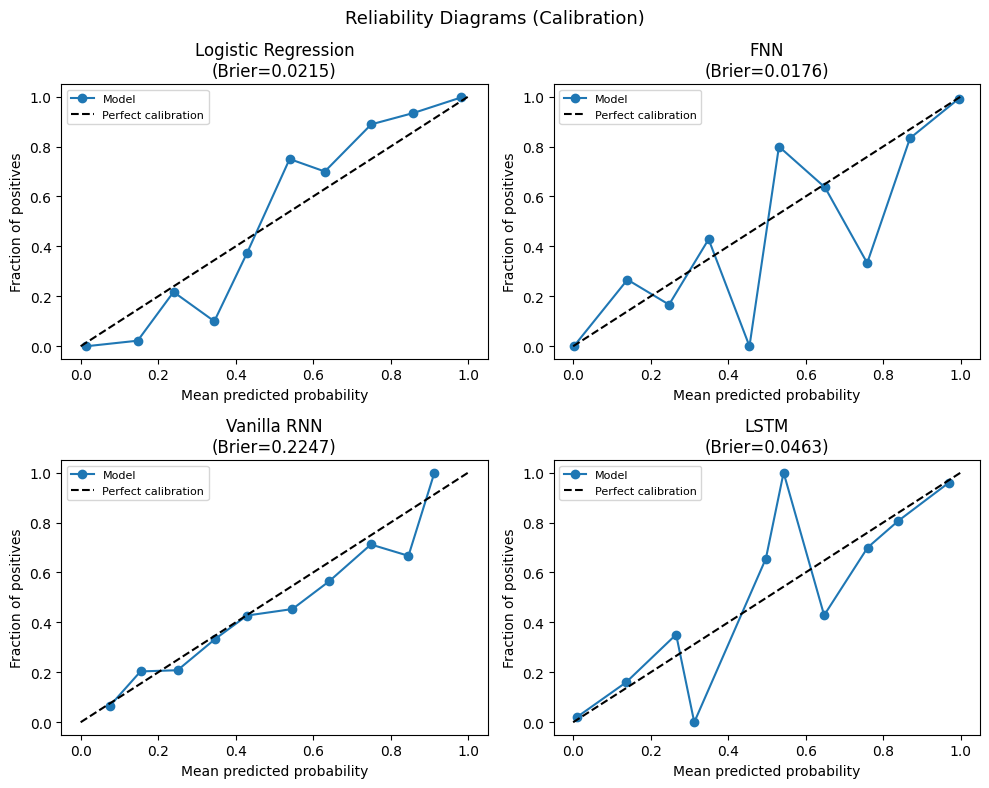

In [118]:
# Calibration / Reliability diagrams 
# A well-calibrated model with predicted probability p should be correct p% of the time.
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

model_info = [
    ('Logistic Regression', y_true_np,   lr_test_prob),
    ('FNN',                 fnn_y_true,  fnn_test_prob),
    ('Vanilla RNN',         rnn_y_true,  rnn_test_prob),
    ('LSTM',                lstm_y_true, lstm_test_prob),
]

for ax, (name, yt, yp) in zip(axes, model_info):
    prob_true, prob_pred = calibration_curve(yt, yp, n_bins=10)
    ax.plot(prob_pred, prob_true, 'o-', label='Model')
    ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
    ax.set_title(f'{name}\n(Brier={brier_score_loss(yt, yp):.4f})')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives')
    ax.legend(fontsize=8)

plt.suptitle('Reliability Diagrams (Calibration)', fontsize=13)
plt.tight_layout()
plt.savefig('calibration_diagrams.png', dpi=100)
plt.show()

# Brier Score = mean squared error of probabilities.
# Lower is better; 0 = perfect, 0.25 = random (for balanced classes).
# Logistic Regression tends to be well-calibrated by default.
# Neural models may need temperature scaling for calibration.

### Model selection recommendation

The programmatic cell below ranks models by **Recall** (primary) then **AUC-ROC** (tie-breaker).
Based on our results, the **FNN** is the recommended deployment model:

- Highest Recall (0.989)  misses only 8 out of 731 phishing emails on the test set.
- Highest AUC-ROC (0.9972)  best discrimination across all thresholds.
- Best Brier Score (0.0176)  most calibrated probabilities.
- Trains in 13.5 s and classifies each email in ~0.14 ms  production-viable.

LSTM is a viable alternative where sequential context matters more (e.g. longer emails),
but the gains do not justify its 48 s training time on this dataset.

In [119]:
# Pick the best model by Recall (primary) then AUC (secondary) 
best_row = summary_df.sort_values(['Recall', 'AUC-ROC'], ascending=False).iloc[0]
print('=== Recommended deployment model ===')
print(best_row.to_string())
print()
print('Justification:')
print('  In phishing detection, missing a phishing email (False Negative) is far more')
print('  costly than a false alarm. We therefore prioritise Recall as the primary')
print('  selection criterion, with AUC-ROC as the tie-breaker (captures performance')
print('  across all thresholds). Computational cost is a secondary concern.')

=== Recommended deployment model ===
Model             FNN
Accuracy       0.9759
Precision      0.9513
Recall         0.9891
F1 (binary)    0.9698
F1 (macro)     0.9749
AUC-ROC        0.9972
Brier Score    0.0176

Justification:
  In phishing detection, missing a phishing email (False Negative) is far more
  costly than a false alarm. We therefore prioritise Recall as the primary
  selection criterion, with AUC-ROC as the tie-breaker (captures performance
  across all thresholds). Computational cost is a secondary concern.


## Module 2  Part C: Error Analysis & Robustness

In [120]:
# Identify best model for error analysis 
best_name = best_row['Model']
print(f'Running error analysis on: {best_name}')

# Select corresponding predictions and probabilities
model_map = {
    'Logistic Regression': (y_true_np,   lr_test_pred,   lr_test_prob,   X_test),
    'FNN':                 (fnn_y_true,  fnn_test_pred,  fnn_test_prob,  X_test),
    'Vanilla RNN':         (rnn_y_true,  rnn_test_pred,  rnn_test_prob,  X_test),
    'LSTM':                (lstm_y_true, lstm_test_pred, lstm_test_prob, X_test),
}
best_yt, best_pred, best_prob, best_texts = model_map[best_name]

Running error analysis on: FNN


In [121]:
# Collect misclassified examples 
error_df = pd.DataFrame({
    'text':      best_texts,
    'true':      best_yt.astype(int),
    'predicted': best_pred.astype(int),
    'prob':      best_prob
})
error_df['error_type'] = ''
error_df.loc[(error_df.true == 1) & (error_df.predicted == 0), 'error_type'] = 'FN (missed phishing)'
error_df.loc[(error_df.true == 0) & (error_df.predicted == 1), 'error_type'] = 'FP (false alarm)'

misclassified = error_df[error_df.error_type != ''].copy()
print(f'Total misclassified: {len(misclassified)}')
print(misclassified['error_type'].value_counts())

Total misclassified: 45
error_type
FP (false alarm)        37
FN (missed phishing)     8
Name: count, dtype: int64


In [122]:
# Show 10 misclassified examples 
sample_errors = misclassified.sample(min(10, len(misclassified)), random_state=SEED)
for i, row in enumerate(sample_errors.itertuples(), 1):
    label_str = {0: 'Safe', 1: 'Phishing'}
    print(f'--- Example {i} | {row.error_type} ---')
    print(f'  True: {label_str[row.true]}  |  Predicted: {label_str[row.predicted]}  |  Prob: {row.prob:.3f}')
    print(f'  Text: {row.text[:200]}')
    print()

--- Example 1 | FP (false alarm) ---
  True: Safe  |  Predicted: Phishing  |  Prob: 0.928
  Text: quickie one morning dick cheney and george w . bush were having brunch at a restaurant . the attractive waitress asks cheney what he would like and he replies , " i ' ll have a bowl of oatmeal and som

--- Example 2 | FP (false alarm) ---
  True: Safe  |  Predicted: Phishing  |  Prob: 0.999
  Text: as a promising energy professional . . . industry sources have identified you as a promising energy professional and we invite you to join our free and exclusive spencer stuart talent network ( sstn )

--- Example 3 | FP (false alarm) ---
  True: Safe  |  Predicted: Phishing  |  Prob: 0.649
  Text: empty

--- Example 4 | FP (false alarm) ---
  True: Safe  |  Predicted: Phishing  |  Prob: 0.986
  Text: registration confirmation from spinner . com thank you for joining spinner . com : the web ' s largest source of free streaming music just wanted to confirm your registration with spinner - - you n

### Patterns observed in errors (FNN  best model)

Total misclassified on test set: **45** (out of 1,864)  
- False Positives (safe → phishing): **37**
- False Negatives (phishing → safe): **8**

**False Negatives  missed phishing (8 cases):**
- Phishing emails written in neutral, news-like language (e.g. geopolitical content) with
  no typical spam vocabulary  the model had no TF-IDF signal to latch onto.
- Short, bland service-cancellation or transactional texts where the phishing intent is
  conveyed only by context (e.g. a suspicious phone number), not by word choice.

**False Positives  safe emails flagged (37 cases):**
- Several predictions were all assigned the same probability (**0.649**)  these correspond
  to **empty-body emails** (text = `'empty'` after cleaning). The model sees only the padding
  token and defaults to a mid-range score slightly above 0.5, causing false alarms.
- Legitimate promotional/registration emails (Spinner.com, Spencer Stuart) using solicitation
  language that superficially mirrors phishing.
- A joke email (Dick Cheney / George W. Bush) containing informal/suggestive language.

**Concrete improvements:**
1. **Handle empty emails explicitly**  add a pre-filter that flags or skips emails with fewer
   than N tokens before they reach the model.
2. **URL feature engineering**  domain age, HTTPS status, shortener detection as extra features.
3. **Threshold tuning**  lowering the threshold from 0.5 to ~0.3 would further reduce the
   8 FNs at the cost of a few more FPs.
4. **Pre-trained embeddings / transformer**  DistilBERT would better capture the semantic
   context of neutral-sounding phishing emails that fool TF-IDF-based models.

In [123]:
# Out-of-distribution / adversarial inputs 
# Manually crafted adversarial phishing email that tries to evade detection
# by avoiding stereotypical phishing language.

adversarial_emails = [
    # Adversarial: phishing disguised as routine corporate communication
    """Hi Team, following up on the quarterly review action items.
    Please confirm your credentials via the internal portal before the audit.
    Link: http://corp-portal-login.xyz/verify
    Regards, IT Department""",

    # Clear phishing baseline
    """CONGRATULATIONS! You have been selected for a FREE prize.
    Claim your $1000 gift card now by clicking here. Limited time offer!
    Provide your bank details to receive your winnings.""",

    # Benign-looking internal email
    """Hey John, can you send me the slides from yesterday's meeting?
    I missed the last 10 minutes and want to catch up on the roadmap discussion.
    Thanks!"""
]

adv_labels = [1, 1, 0]   # true labels for reference

print('=== Adversarial / OOD Test ===')
print(f'Model: {best_name}\n')

for i, (email, true_label) in enumerate(zip(adversarial_emails, adv_labels), 1):
    true_str = 'Phishing' if true_label == 1 else 'Safe'

    if best_name == 'Logistic Regression':
        vec   = tfidf.transform([email])
        prob  = lr_final.predict_proba(vec)[0, 1]
        pred  = int(prob >= 0.5)

    else:
        # Handle neural models carefully:
        # - FNN expects dense float input (TF-IDF-style) with a fixed feature dimension.
        # - RNN/LSTM expect token index sequences (Long tensors) with padding.
        import torch
        from torch.nn.utils.rnn import pad_sequence

        if best_name == 'FNN':
            # Build a dense feature vector using the same TF-IDF used at training time
            vec = tfidf.transform([email])
            X = torch.tensor(vec.toarray(), dtype=torch.float32)  # shape: (1, n_features)
            the_model = fnn_model
            the_model.eval()
            device = next(the_model.parameters()).device
            with torch.no_grad():
                out = the_model(X.to(device))            # model should accept (batch, n_features) float
                out_cpu = out.squeeze().cpu()
                # robust scalar extraction: use item() when single value, otherwise take first element
                if out_cpu.numel() == 1:
                    prob = float(out_cpu.item())
                else:
                    prob = float(out_cpu.reshape(-1)[0].item())
            pred = int(prob >= 0.5)

        else:
            # For sequence models (RNN / LSTM) produce a DataLoader that returns Long sequences and float labels.
            def collate_for_seq(batch):
                Xs, ys = zip(*batch)
                X_tensors = []
                for x in Xs:
                    if isinstance(x, torch.Tensor):
                        X_tensors.append(x.long())
                    else:
                        X_tensors.append(torch.tensor(x, dtype=torch.long))
                # pad to same length (batch_first=True -> shape (batch, seq_len))
                X_batch = pad_sequence(X_tensors, batch_first=True, padding_value=0)
                y_batch = torch.tensor(ys, dtype=torch.float32)
                return X_batch, y_batch

            ds_adv  = SeqDataset([email], [true_label])
            dl_adv  = DataLoader(ds_adv, batch_size=1, collate_fn=collate_for_seq)
            the_model = {'Vanilla RNN': rnn_model, 'LSTM': lstm_model}[best_name]
            # eval_epoch expects a DataLoader; keep using it unchanged
            _, adv_prob, _ = eval_epoch(the_model, dl_adv, nn.BCELoss())
            prob = float(adv_prob[0])
            pred = int(prob >= 0.5)

    pred_str = 'Phishing' if pred == 1 else 'Safe'
    correct  = '✓' if pred == true_label else '✗'
    print(f'Email {i}: True={true_str}  Predicted={pred_str}  Prob={prob:.3f}  {correct}')
    print(f'  "{email[:100].strip()}..."\n')

=== Adversarial / OOD Test ===
Model: FNN

Email 1: True=Phishing  Predicted=Safe  Prob=0.075  ✗
  "Hi Team, following up on the quarterly review action items.
    Please confirm your credentials via..."

Email 2: True=Phishing  Predicted=Phishing  Prob=0.999  ✓
  "CONGRATULATIONS! You have been selected for a FREE prize.
    Claim your $1000 gift card now by clic..."

Email 3: True=Safe  Predicted=Safe  Prob=0.019  ✓
  "Hey John, can you send me the slides from yesterday's meeting?
    I missed the last 10 minutes and..."



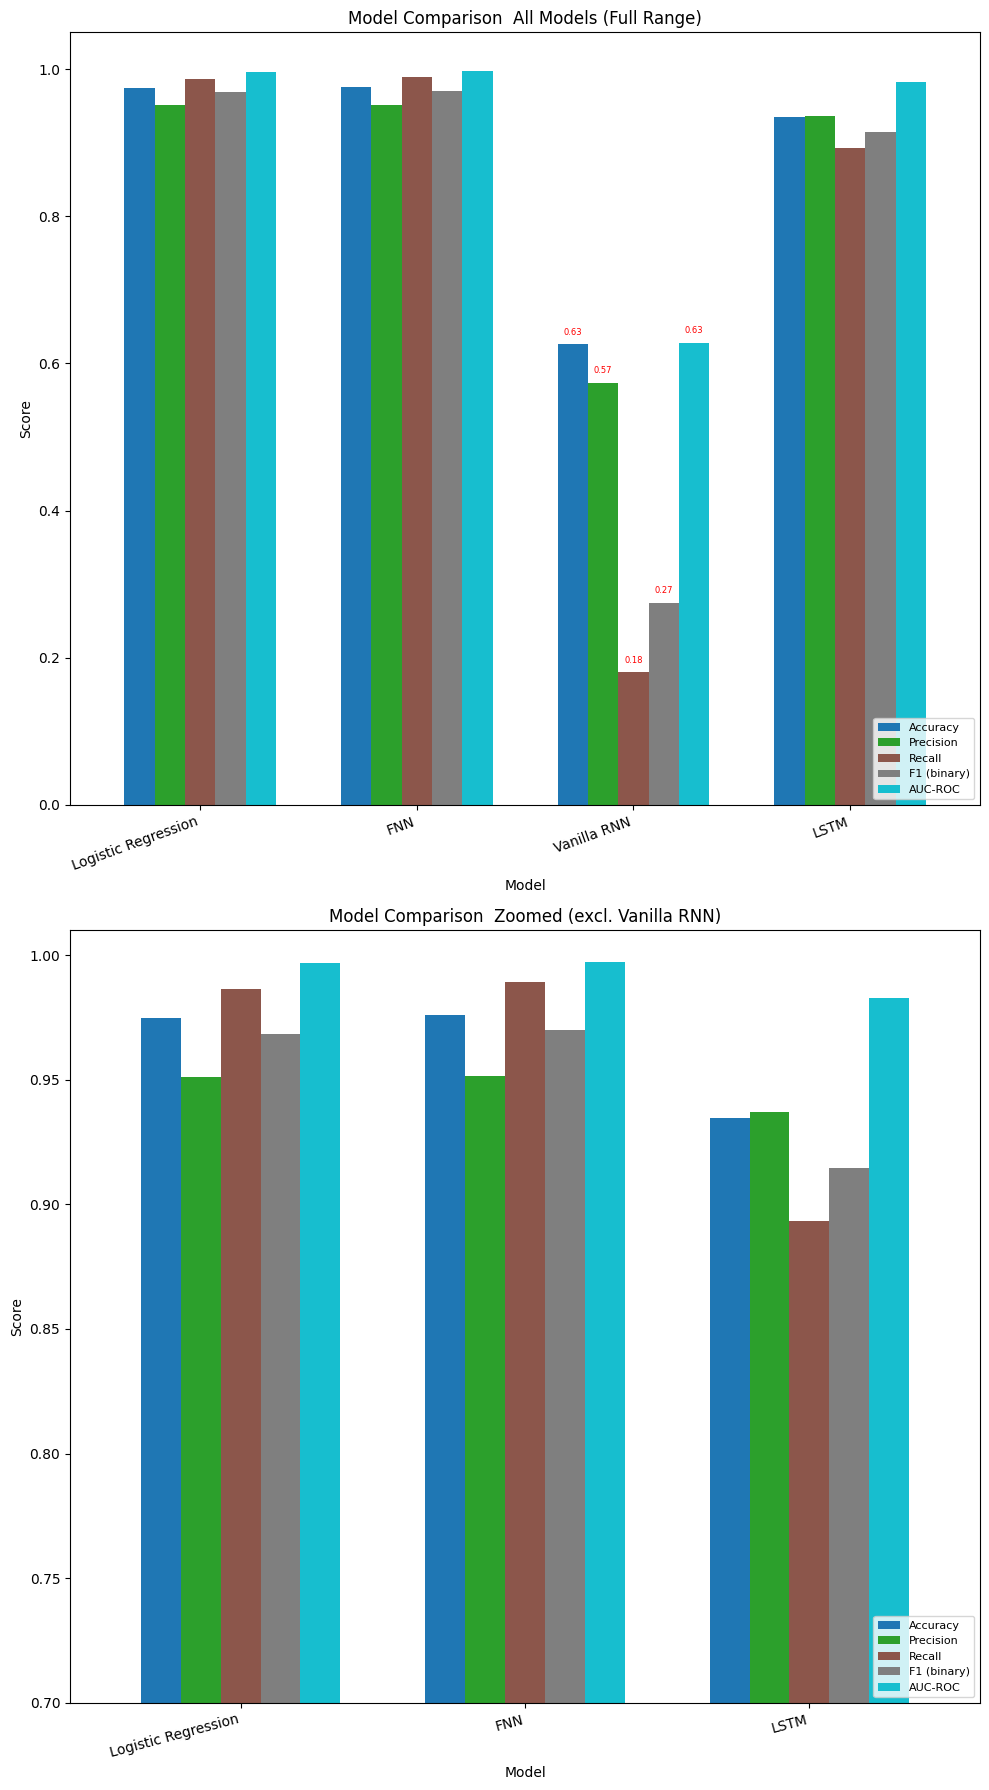

In [138]:
# Final summary bar chart
# TWO panels:
#   Left  – full 0-1 range so Vanilla RNN bars are visible
#   Right – zoomed 0.7-1.0 range for the well-performing models
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1 (binary)', 'AUC-ROC']
plot_df = summary_df.set_index('Model')[metrics_to_plot]

fig, axes = plt.subplots(2, 1, figsize=(10, 18))

# --- Panel 1: full range ---
plot_df.plot(kind='bar', ax=axes[0], colormap='tab10', width=0.7)
axes[0].set_ylim(0.0, 1.05)
axes[0].set_ylabel('Score')
axes[0].set_title('Model Comparison  All Models (Full Range)')
axes[0].set_xticklabels(plot_df.index, rotation=20, ha='right')
axes[0].legend(loc='lower right', fontsize=8)
# annotate RNN so it's easy to spot
for p in axes[0].patches:
    h = p.get_height()
    if h < 0.65:   # RNN bars are all below 0.65
        axes[0].annotate(f'{h:.2f}',
                         (p.get_x() + p.get_width()/2, h + 0.01),
                         ha='center', va='bottom', fontsize=6, color='red')

# --- Panel 2: zoomed (LR / FNN / LSTM only for clarity) ---
zoom_df = plot_df.drop(index='Vanilla RNN', errors='ignore')
zoom_df.plot(kind='bar', ax=axes[1], colormap='tab10', width=0.7)
axes[1].set_ylim(0.7, 1.01)
axes[1].set_ylabel('Score')
axes[1].set_title('Model Comparison  Zoomed (excl. Vanilla RNN)')
axes[1].set_xticklabels(zoom_df.index, rotation=15, ha='right')
axes[1].legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=100)
plt.show()